# DataIO Example: AGN FOV Time Cut

This example reads a DC4 unbinned AGN FITS file, builds good time intervals for a source using the default COSI field-of-view cut, and writes a binned `.hdf5` file containing events either inside or outside that FOV selection.

The FOV selection uses `GoodTimeInterval.from_pointing_cut`, with the default example value `max_offaxis = 60 * u.deg`. Set `keep_source_in_fov = False` to keep events when the source is outside the FOV instead.

In [1]:
from pathlib import Path
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from histpy import Histogram

from cosipy import BinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.spacecraftfile import SpacecraftHistory

%matplotlib inline

22:29:15 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=102144;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=801859;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=548792;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=682248;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=852082;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=645414;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

22:29:15 INFO      Starting 3ML!                                                                     ]8;id=602509;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=928681;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=499072;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=701313;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

22:29:16 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=314182;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=744645;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=244941;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=1097;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=530025;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=463431;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=807618;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=846063;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=28279;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=343384;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [18]:
# ### Data file to apply pointing cuts
# data_file = Path(
#     "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits"
# )

# ### Reference file to compare the GTI data
# reference_binned_file = Path(
#     "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
# )

### Data file to apply pointing cuts
data_file = Path(
    "/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_unbinned_data_filtered_with_SAAcut.fits"
)

### Reference file to compare the GTI data
reference_binned_file = Path(
    "/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_binned_data_filtered_with_SAAcut.hdf5"
)

### Data file to apply pointing cuts (Mock data)
# data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered.fits"
# )

### Reference file to compare the GTI data (Mock data)
# reference_binned_file = Path(
#     "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5"
# )

orientation_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)

### This config is only used to initialize the DataIO object. The data and orientation paths are set explicitly above for this example.
config_file = Path("inputs.yaml")

### Change details below for the source to be analyzed
source_name = "NGC 4151"
source_coord = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")

### Default FOV cut used by the pointing-cut helper.
max_offaxis = 60 * u.deg
earth_occ = True

### Switch to False to keep events when the source is outside the FOV.
keep_source_in_fov = True

selection_label = "in_fov" if keep_source_in_fov else "out_of_fov"
binned_output_prefix = data_file.with_name(f"{data_file.stem}_ngc4151_{selection_label}_binned")

Read the unbinned FITS data and open the spacecraft orientation over the event time range.

In [19]:
analysis = BinnedData(str(config_file))
analysis.data_file = str(data_file)
analysis.ori_file = str(orientation_file)
analysis.unbinned_output = "fits"

analysis.cosi_dataset = analysis.get_dict(str(data_file))
time_tags = analysis.cosi_dataset["TimeTags"]

event_tstart = Time(np.min(time_tags), format="unix", scale="utc")
event_tstop = Time(np.max(time_tags), format="unix", scale="utc")

sc_history = SpacecraftHistory.open(
    orientation_file,
    tstart=event_tstart,
    tstop=event_tstop,
).select_interval(event_tstart, event_tstop)

print(f"Input events: {len(time_tags):,}")
print(f"Event time range: {event_tstart.isot} to {event_tstop.isot}")
print(f"Orientation pointings: {len(sc_history.obstime):,}")

Input events: 72,697
Event time range: 2028-03-01T02:21:45.128 to 2028-06-01T10:04:08.992
Orientation pointings: 531,771


Build the GTIs where the source is inside the FOV.

In [20]:
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_history,
    max_offaxis,
    earth_occ=earth_occ,
)

gti_livetime = sc_history.apply_gti(source_gti).cumulative_livetime().to_value(u.s)
total_livetime = sc_history.cumulative_livetime().to_value(u.s)
livetime_fraction = gti_livetime / total_livetime

print(f"Source: {source_name}")
print(f"FOV cut: off-axis <= {max_offaxis.to_value(u.deg):.1f} deg")
print(f"GTI intervals: {len(source_gti)}")
print(f"GTI livetime: {gti_livetime:,.1f} s")
print(f"Total livetime: {total_livetime:,.1f} s")
print(f"Livetime fraction in FOV: {livetime_fraction:.4f}")

# for start, stop in list(source_gti)[:5]:
#     print(f"{start.isot}  to  {stop.isot}")

# if len(source_gti) > 5:
#     print("...")

Source: NGC 4151
FOV cut: off-axis <= 60.0 deg
GTI intervals: 675
GTI livetime: 980,415.0 s
Total livetime: 6,576,668.9 s
Livetime fraction in FOV: 0.1491


Inspect the source off-axis angle. The horizontal line is the FOV threshold used to build the GTIs.

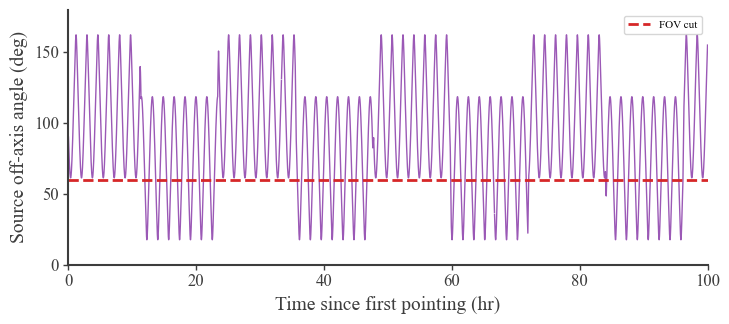

In [10]:
source_sc = sc_history.get_target_in_sc_frame(source_coord)
offaxis = (np.pi / 2 * u.rad - source_sc.lat).to_value(u.deg)
time_hours = (sc_history.obstime.unix - sc_history.obstime.unix[0]) / 3600

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_hours, offaxis, lw=1)
ax.axhline(max_offaxis.to_value(u.deg), color="tab:red", ls="--", label="FOV cut")
ax.set_xlabel("Time since first pointing (hr)")
ax.set_ylabel("Source off-axis angle (deg)")
ax.set_ylim(0, 180)
ax.set_xlim(0, 100)
ax.legend()
fig.tight_layout()

Convert the GTIs into an event-level mask. This applies the same half-open convention as `select_data_time`: events are kept for `start <= TimeTags < stop`.

In [11]:
gti_start = Time([start for start, stop in source_gti]).unix
gti_stop = Time([stop for start, stop in source_gti]).unix

interval_idx = np.searchsorted(gti_start, time_tags, side="right") - 1

in_fov_mask = np.zeros(len(time_tags), dtype=bool)
valid_interval = interval_idx >= 0
in_fov_mask[valid_interval] = time_tags[valid_interval] < gti_stop[interval_idx[valid_interval]]

n_in_fov = np.count_nonzero(in_fov_mask)
n_out_fov = len(in_fov_mask) - n_in_fov

selection_mask = in_fov_mask if keep_source_in_fov else ~in_fov_mask

print(f"Events in FOV: {n_in_fov:,}")
print(f"Events outside FOV: {n_out_fov:,}")
print(f"Events selected ({selection_label}): {np.count_nonzero(selection_mask):,}")

Events in FOV: 54,915
Events outside FOV: 17,782
Events selected (in_fov): 54,915


Apply the mask, bin the selected events, and write the binned histogram as an `.hdf5` file.

In [12]:
analysis.cosi_dataset = {
    key: values[selection_mask]
    for key, values in analysis.cosi_dataset.items()
}

selected_time_tags = analysis.cosi_dataset["TimeTags"]
analysis.tmin = float(np.min(selected_time_tags))
analysis.tmax = float(np.max(selected_time_tags))

In [13]:
analysis.get_binned_data(
    output_name=str(binned_output_prefix),
    make_binning_plots=False,
    show_plots=False,
)

print(f"Wrote: {binned_output_prefix}.hdf5")

Wrote: /Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_unbinned_data_filtered_with_SAAcut_ngc4151_in_fov_binned.hdf5


Compare the FOV-selected binned histogram to the full binned mock-data histogram and the DC4 background histogram.

Full binned counts: 72,696
FOV-selected binned counts: 54,914
Count fraction: 0.7554


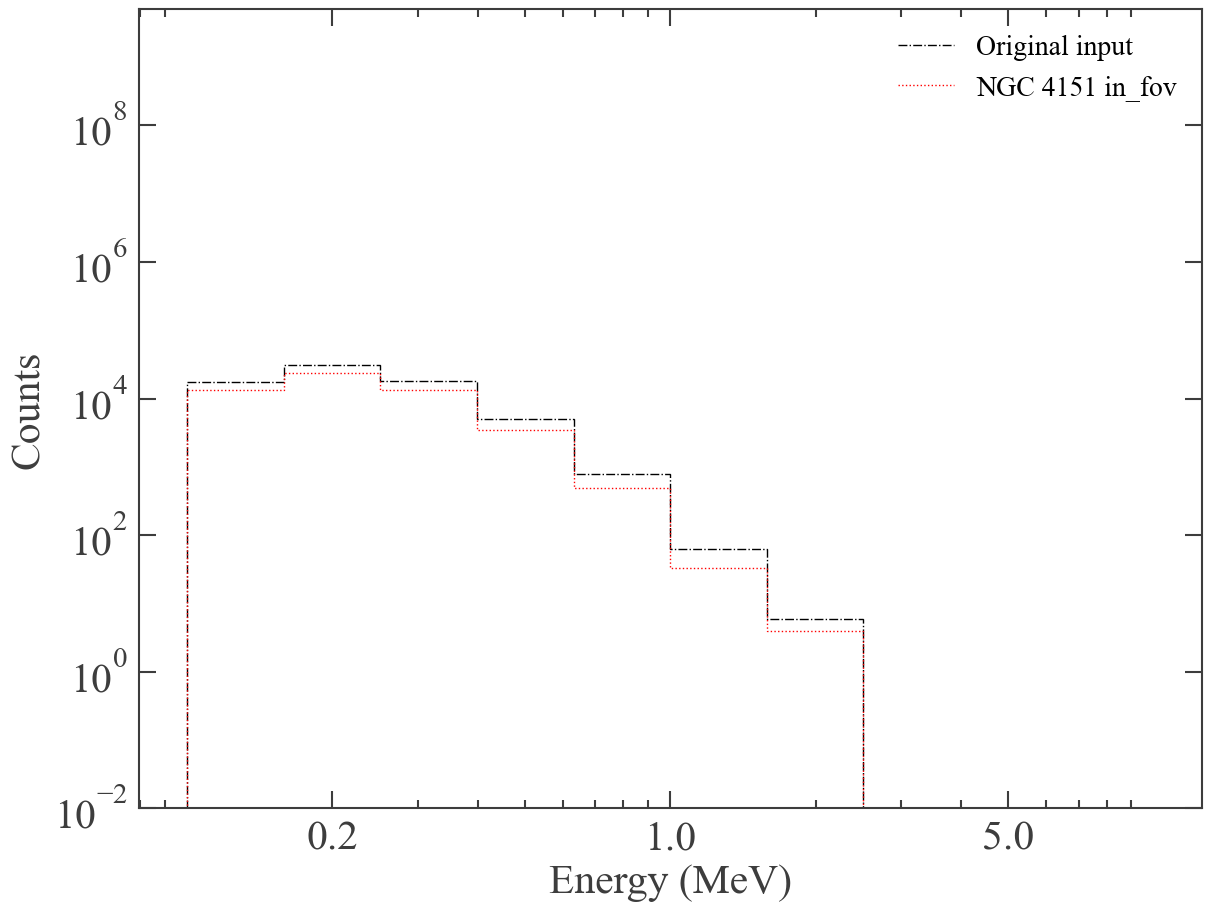

In [21]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})

time_cut_hist = Histogram.open(f"{binned_output_prefix}.hdf5")
reference_hist = Histogram.open(reference_binned_file)

def projection_counts(hist, axis_name):
    return hist.project(axis_name).to_dense(copy=False).contents


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


time_cut_counts = projection_counts(time_cut_hist, "Time")
reference_counts = projection_counts(reference_hist, "Time")

time_cut_time_edges = time_cut_hist.axes["Time"].edges.to_value(u.s)
reference_time_edges = reference_hist.axes["Time"].edges.to_value(u.s)
time_zero = reference_time_edges[0]

time_cut_energy_counts = projection_counts(time_cut_hist, "Em")
reference_energy_counts = projection_counts(reference_hist, "Em")
time_cut_energy_edges = time_cut_hist.axes["Em"].edges.to_value(u.keV)
reference_energy_edges = reference_hist.axes["Em"].edges.to_value(u.keV)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)
ax.stairs(reference_energy_counts, reference_energy_edges / 1000, label="Original input", color="black", linestyle="dashdot")
ax.stairs(time_cut_energy_counts, time_cut_energy_edges / 1000, label=f"{source_name} {selection_label}", color="red", linestyle="dotted")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e9)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc="upper right", frameon=False)

print(f"Full binned counts: {np.sum(reference_counts):,.0f}")
print(f"FOV-selected binned counts: {np.sum(time_cut_counts):,.0f}")
print(f"Count fraction: {np.sum(time_cut_counts) / np.sum(reference_counts):.4f}")